In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from phase_2.utils.paths import PROCESSED_DIR


In [2]:
SYMBOLS = [
    "SPY", "QQQ", "IWM",
    "AAPL", "MSFT", "NVDA",
    "XLU", "XLV", "XLP",
    "XLF", "XLE", "XLI",
]

data = {}

for sym in SYMBOLS:
    df = pd.read_parquet(PROCESSED_DIR / f"{sym.lower()}_daily.parquet")
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df["year"] = df["date"].dt.year
    data[sym] = df

years = sorted(data["SPY"]["year"].unique())
years[:5], years[-5:]


([np.int32(2010),
  np.int32(2011),
  np.int32(2012),
  np.int32(2013),
  np.int32(2014)],
 [np.int32(2022),
  np.int32(2023),
  np.int32(2024),
  np.int32(2025),
  np.int32(2026)])

In [3]:
# Phase 2 strategies
from phase_2.scripts.strategies.trend.trend_strategy_v1 import run_trend_strategy_v1
from phase_2.scripts.strategies.meanrev.meanrev_strategy_v1 import run_meanrev_strategy_v1

# Phase 2 meta allocator & regime features
from phase_2.scripts.strategies.meta.meta_allocator_v1 import (
    build_regime_features,
    build_meta_raw_returns_param_v1,
)

# Phase 3 gates
from phase_3.strategies.meta.strategy_gates_v1 import apply_strategy_gates
# Portfolio plumbing
from phase_2.scripts.strategies.meta.risk_targeting_v1 import apply_vol_targeting
from phase_2.scripts.strategies.portfolio.portfolio_constructor_v1 import (
    align_asset_returns,
    compute_inverse_vol_weights,
    build_portfolio_raw_returns,
)
from phase_4.scripts.portfolio.risk_caps_v1 import (apply_all_risk_caps, SECTOR_MAP)


In [4]:
HARD_PARAMS_TIGHT = {
    "trend_mom60_min": 0.0,
    "trend_mom20_min": -0.005,
    "meanrev_mom20_max": -0.025,
    "meanrev_dd60_max": -0.03,
    "meanrev_vol20_max": 0.40,
}

In [5]:
def sharpe_ratio(x: pd.Series) -> float:
    x = x.values
    if np.std(x) == 0:
        return np.nan
    return np.sqrt(252) * np.mean(x) / np.std(x)

def max_drawdown_from_returns(r: pd.Series) -> float:
    eq = (1 + r).cumprod().values
    peak = np.maximum.accumulate(eq)
    dd = eq / peak - 1.0
    return dd.min()

def compute_turnover(w: pd.DataFrame) -> pd.DataFrame:
    """
    Daily turnover: sum_i |w_t,i - w_{t-1,i}|
    """
    w_shift = w.shift(1)
    diff = (w - w_shift).abs().sum(axis=1)

    out = pd.DataFrame({
        "date": w.index,
        "turnover": diff,
    })
    out["year"] = out["date"].dt.year
    return out

In [6]:
def compute_risk_contribution_snapshot(ret_wide: pd.DataFrame, weights: pd.DataFrame) -> pd.DataFrame:
    """
    Use last 252 days in ret_wide for covariance.
    Use last row of weights for portfolio weights.
    """
    asset_cols = list(ret_wide.columns)

    snapshot = ret_wide.dropna().iloc[-252:]
    cov = snapshot[asset_cols].cov()  # daily covariance

    w_last = weights.dropna().iloc[-1][asset_cols].values
    w_vec = w_last.reshape(-1, 1)

    port_var = float(w_vec.T @ cov.values @ w_vec)
    marginal = cov.values @ w_vec
    rc = (w_vec * marginal).flatten()
    rc_frac = rc / port_var

    return (
        pd.DataFrame({
            "asset": asset_cols,
            "weight": w_last,
            "risk_contribution_frac": rc_frac,
        })
        .sort_values("risk_contribution_frac", ascending=False)
        .reset_index(drop=True)
    )


In [7]:
# -------------------------------
# Walk-forward with and without caps
# -------------------------------

portfolio_baseline_all = []
portfolio_capped_all = []

weights_baseline_all = []
weights_capped_all = []

for test_year in years:
    asset_daily = {}

    for sym in SYMBOLS:
        df = data[sym]
        train = df[df["year"] < test_year]
        test  = df[df["year"] == test_year]

        if len(train) < 500 or len(test) < 60:
            continue

        # 1) Strategy outputs
        trend = run_trend_strategy_v1(test, train_df=train)
        meanr = run_meanrev_strategy_v1(test)
        regime = build_regime_features(test)

        # 2) Apply gates
        trend, meanr = apply_strategy_gates(trend, meanr, regime)

        # 3) Meta allocator: combine trend + meanrev into meta_raw_ret
        meta = build_meta_raw_returns_param_v1(
            trend,
            meanr,
            regime,
            HARD_PARAMS_TIGHT,
        )

        meta["asset"] = sym
        meta["year"] = test_year

        asset_daily[sym] = meta[["date", "asset", "year", "meta_raw_ret"]]

    # Ensure we have all symbols for this year
    if len(asset_daily) != len(SYMBOLS):
        continue

    # 4) Align per-asset returns into wide matrix
    ret_wide = align_asset_returns(asset_daily)  # index=date, columns=SYMBOLS

    # 5) Raw inverse-vol weights (baseline)
    w_raw = compute_inverse_vol_weights(
        ret_wide,
        lookback=20,
        max_weight=0.70,   # pre-cap raw max
    )

    # 6) Capped weights (Phase 5A)
    w_capped = apply_all_risk_caps(
        w_raw,
        sector_map=SECTOR_MAP,
        max_weight_per_asset=0.20,
        max_sector_weight=0.40,
        min_assets_held=6,
    )

    # 7) Build raw portfolio returns for both
    port_raw_baseline = build_portfolio_raw_returns(ret_wide, w_raw)
    port_raw_capped   = build_portfolio_raw_returns(ret_wide, w_capped)

    # 8) Apply portfolio-level vol targeting (same target)
    vt_baseline = apply_vol_targeting(
        port_raw_baseline,
        target_vol_annual=0.10,
        lookback=20,
        max_leverage=1.0,
    )

    vt_capped = apply_vol_targeting(
        port_raw_capped,
        target_vol_annual=0.10,
        lookback=20,
        max_leverage=1.0,
    )

    # 9) Store portfolio series
    portfolio_baseline_all.append(
        pd.DataFrame({
            "date": port_raw_baseline.index,
            "portfolio_ret": vt_baseline["meta_ret"].values,
            "portfolio_lev": vt_baseline["lev"].values,
            "year": test_year,
        })
    )

    portfolio_capped_all.append(
        pd.DataFrame({
            "date": port_raw_capped.index,
            "portfolio_ret": vt_capped["meta_ret"].values,
            "portfolio_lev": vt_capped["lev"].values,
            "year": test_year,
        })
    )

    # 10) Store weights (wide) with date + year for diagnostics
    for label, w_mat, store in [
        ("baseline", w_raw, weights_baseline_all),
        ("capped",   w_capped, weights_capped_all),
    ]:
        w_df = w_mat.copy()
        w_df["date"] = w_df.index
        w_df["year"] = test_year
        store.append(w_df.reset_index(drop=True))


In [8]:
# -------------------------------
# Combine per-year results
# -------------------------------
portfolio_baseline = (
    pd.concat(portfolio_baseline_all)
    .sort_values("date")
    .reset_index(drop=True)
)

portfolio_capped = (
    pd.concat(portfolio_capped_all)
    .sort_values("date")
    .reset_index(drop=True)
)

weights_baseline = (
    pd.concat(weights_baseline_all)
    .sort_values("date")
    .set_index("date")
)

weights_capped = (
    pd.concat(weights_capped_all)
    .sort_values("date")
    .set_index("date")
)

portfolio_baseline.head(), portfolio_capped.head()


(        date  portfolio_ret  portfolio_lev  year
 0 2012-01-03            0.0            0.0  2012
 1 2012-01-04            0.0            0.0  2012
 2 2012-01-05            0.0            0.0  2012
 3 2012-01-06            0.0            0.0  2012
 4 2012-01-09            0.0            0.0  2012,
         date  portfolio_ret  portfolio_lev  year
 0 2012-01-03            0.0            0.0  2012
 1 2012-01-04            0.0            0.0  2012
 2 2012-01-05            0.0            0.0  2012
 3 2012-01-06            0.0            0.0  2012
 4 2012-01-09            0.0            0.0  2012)

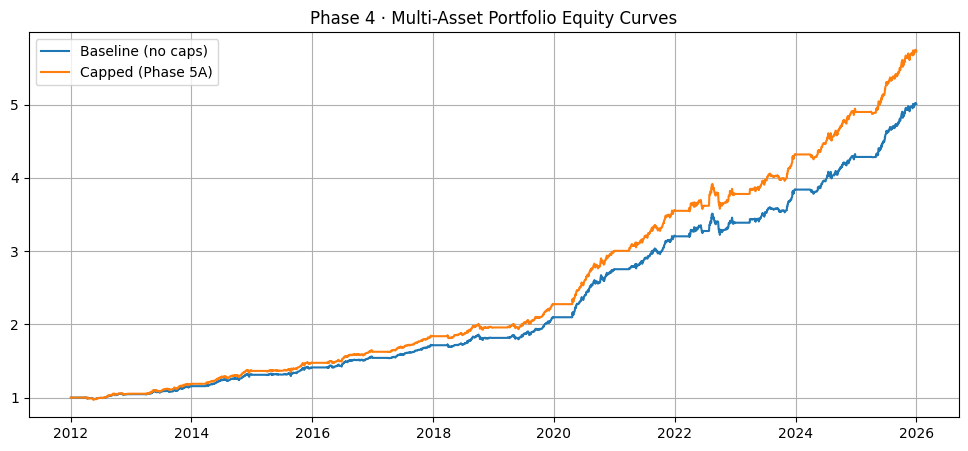

In [ ]:
# -------------------------------
# Equity curves: baseline vs capped
# -------------------------------

eq_base = (1 + portfolio_baseline["portfolio_ret"]).cumprod()
eq_caps = (1 + portfolio_capped["portfolio_ret"]).cumprod()

plt.figure(figsize=(12,5))
plt.plot(portfolio_baseline["date"], eq_base, label="Baseline (no caps)")
plt.plot(portfolio_capped["date"],   eq_caps, label="Capped (Phase 4)")
plt.title("Phase 4 · Multi-Asset Portfolio Equity Curves")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
# -------------------------------
# Yearly performance: baseline vs capped
# -------------------------------

rows = []

for y in sorted(portfolio_baseline["year"].unique()):
    gb = portfolio_baseline[portfolio_baseline["year"] == y]
    gc = portfolio_capped[portfolio_capped["year"] == y]

    rows.append({
        "year": y,
        "sharpe_base": sharpe_ratio(gb["portfolio_ret"]),
        "ret_base": (1 + gb["portfolio_ret"]).prod() - 1,
        "mdd_base": max_drawdown_from_returns(gb["portfolio_ret"]),
        "avgLev_base": gb["portfolio_lev"].mean(),

        "sharpe_caps": sharpe_ratio(gc["portfolio_ret"]),
        "ret_caps": (1 + gc["portfolio_ret"]).prod() - 1,
        "mdd_caps": max_drawdown_from_returns(gc["portfolio_ret"]),
        "avgLev_caps": gc["portfolio_lev"].mean(),
    })

summary = pd.DataFrame(rows)
summary["sharpe_diff"] = summary["sharpe_caps"] - summary["sharpe_base"]
summary["mdd_diff"]    = summary["mdd_caps"]   - summary["mdd_base"]
summary


,year,sharpe_base,ret_base,mdd_base,avgLev_base,sharpe_caps,ret_caps,mdd_caps,avgLev_caps,sharpe_diff,mdd_diff
0,2012,1.236129,0.047004,-0.029032,0.924000,1.315308,0.053409,-0.034168,0.924000,0.079179,-5.136037e-03
1,2013,2.130349,0.104432,-0.021869,0.924603,2.476063,0.128306,-0.021869,0.924603,0.345714,1.110223e-16
2,2014,2.592052,0.134175,-0.031320,0.924603,2.786122,0.147854,-0.031320,0.924603,0.194070,0.000000e+00
3,2015,1.450722,0.076456,-0.028183,0.903516,1.491234,0.081220,-0.028230,0.903515,0.040511,-4.729811e-05
4,2016,2.130032,0.092583,-0.019496,0.924603,2.277238,0.102250,-0.019313,0.924603,0.147206,1.830897e-04
5,2017,3.418010,0.111955,-0.009913,0.924303,3.785165,0.130715,-0.009913,0.924303,0.367155,0.000000e+00
6,2018,1.229255,0.058477,-0.038927,0.924303,1.304034,0.064873,-0.039812,0.924284,0.074779,-8.849780e-04
7,2019,2.839695,0.155226,-0.032238,0.924603,2.911053,0.162531,-0.035252,0.924603,0.071358,-3.013874e-03
8,2020,3.825081,0.312552,-0.029292,0.851879,3.830966,0.319715,-0.028908,0.850823,0.005885,3.843049e-04
9,2021,3.013777,0.163155,-0.025665,0.924603,3.141394,0.181964,-0.024376,0.924603,0.127618,1.288842e-03


In [20]:
# -------------------------------
# Turnover: baseline vs capped (daily)
# -------------------------------
turn_base = compute_turnover(weights_baseline)
turn_caps = compute_turnover(weights_capped)

# Drop the first NaN day (no prior weights)
turn_base = turn_base.dropna(subset=["turnover"])
turn_caps = turn_caps.dropna(subset=["turnover"])

# Quick look
turn_base.head(), turn_caps.head()


(                 date  turnover  year
 date                                 
 2012-01-03 2012-01-03       0.0  2012
 2012-01-04 2012-01-04       0.0  2012
 2012-01-05 2012-01-05       0.0  2012
 2012-01-06 2012-01-06       0.0  2012
 2012-01-09 2012-01-09       0.0  2012,
                  date  turnover  year
 date                                 
 2012-01-03 2012-01-03       0.0  2012
 2012-01-04 2012-01-04       0.0  2012
 2012-01-05 2012-01-05       0.0  2012
 2012-01-06 2012-01-06       0.0  2012
 2012-01-09 2012-01-09       0.0  2012)

In [21]:
# -------------------------------
# Annual turnover sums
# -------------------------------
annual_turnover = (
    turn_base.groupby("year")["turnover"].sum()
        .to_frame(name="annual_turnover_base")
    .join(
        turn_caps.groupby("year")["turnover"].sum()
            .to_frame(name="annual_turnover_caps"),
        how="inner"
    )
).reset_index()

annual_turnover


,year,annual_turnover_base,annual_turnover_caps
0,2012,47.104111,32.764259
1,2013,37.967223,28.431160
2,2014,23.499256,18.584306
3,2015,52.070328,36.433899
4,2016,29.610841,23.186663
5,2017,52.066142,34.385243
6,2018,45.808586,32.608201
7,2019,29.473963,22.953995
8,2020,40.643229,27.412214
9,2021,37.038197,25.986919


In [22]:
# Summary stats across all years
turnover_stats = pd.DataFrame({
    "metric": ["mean", "median", "p95"],
    "baseline": [
        turn_base["turnover"].mean(),
        turn_base["turnover"].median(),
        turn_base["turnover"].quantile(0.95),
    ],
    "capped": [
        turn_caps["turnover"].mean(),
        turn_caps["turnover"].median(),
        turn_caps["turnover"].quantile(0.95),
    ],
})
turnover_stats


,metric,baseline,capped
0,mean,0.164340,0.118575
1,median,0.031372,0.030690
2,p95,1.116502,0.631102


In [23]:
# -------------------------------
# Risk contribution snapshot: last year
# -------------------------------
last_year = portfolio_baseline["year"].max()
last_year


np.int32(2025)

In [24]:
asset_daily_last = {}

for sym in SYMBOLS:
    df = data[sym]
    train_last = df[df["year"] < last_year]
    test_last  = df[df["year"] == last_year]

    trend = run_trend_strategy_v1(test_last, train_df=train_last)
    meanr = run_meanrev_strategy_v1(test_last)
    regime = build_regime_features(test_last)
    trend, meanr = apply_strategy_gates(trend, meanr, regime)

    meta = build_meta_raw_returns_param_v1(
        trend,
        meanr,
        regime,
        HARD_PARAMS_TIGHT,
    )
    meta["asset"] = sym

    asset_daily_last[sym] = meta[["date", "asset", "meta_raw_ret"]]

ret_wide_last = align_asset_returns(asset_daily_last)


In [25]:
w_raw_last = compute_inverse_vol_weights(ret_wide_last, lookback=20, max_weight=0.70)
w_caps_last = apply_all_risk_caps(
    w_raw_last,
    sector_map=SECTOR_MAP,
    max_weight_per_asset=0.20,
    max_sector_weight=0.40,
    min_assets_held=6,
)


In [26]:
rc_base = compute_risk_contribution_snapshot(ret_wide_last, w_raw_last)
rc_caps = compute_risk_contribution_snapshot(ret_wide_last, w_caps_last)

print("=== Risk Contribution (Baseline) ===")
print(rc_base)

print("\n=== Risk Contribution (Capped) ===")
print(rc_caps)


=== Risk Contribution (Baseline) ===
   asset    weight  risk_contribution_frac
0   MSFT  0.422021                0.729195
1    SPY  0.057732                0.042765
2    QQQ  0.040055                0.037177
3   AAPL  0.056791                0.033135
4   NVDA  0.025389                0.030927
5    XLU  0.088598                0.028582
6    IWM  0.040377                0.027523
7    XLI  0.042121                0.027272
8    XLF  0.047428                0.014562
9    XLE  0.051075                0.013293
10   XLV  0.042352                0.009289
11   XLP  0.086062                0.006280

=== Risk Contribution (Capped) ===
   asset    weight  risk_contribution_frac
0   MSFT  0.257076                0.447557
1    SPY  0.074208                0.083644
2   AAPL  0.072998                0.071641
3    QQQ  0.051485                0.067208
4    XLU  0.113882                0.060330
5    IWM  0.051899                0.056859
6   NVDA  0.032635                0.054570
7    XLI  0.054141      

/var/folders/5x/hpfg2j9961g4st0gb95whvr80000gn/T/ipykernel_67703/1997425703.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  port_var = float(w_vec.T @ cov.values @ w_vec)
/var/folders/5x/hpfg2j9961g4st0gb95whvr80000gn/T/ipykernel_67703/1997425703.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  port_var = float(w_vec.T @ cov.values @ w_vec)
